# Yêu cầu bài tập
## Phần 1. Tiền xử lý dữ liệu
Thực hiện các yêu cầu sau:

- Chuẩn hóa dữ liệu về khoảng [0, 1] hoặc dùng chuẩn hóa z-score.
- Tạo các chuỗi con với độ dài seq_length = 20.
- Chia dữ liệu theo tỉ lệ:
    - 70% cho tập huấn luyện
    - 15% cho tập validation
    - 15% cho tập kiểm tra

## Phần 2. Xây dựng mô hình RNN
Xây dựng mô hình RNN bằng PyTorch với cấu hình gợi ý như sau:

- input_size = 3
- hidden_size = 32
- output_size = 1

Yêu cầu trong quá trình huấn luyện:

- Sử dụng hàm mất mát MSELoss.
- Sử dụng bộ tối ưu Adam.
- Huấn luyện mô hình trong 150 epochs.
- Lưu lại các giá trị sau:
    - train loss
    - validation loss

## Phần 3. Đánh giá mô hình
Sau khi huấn luyện xong, thực hiện các yêu cầu sau:

- Dự đoán trên tập test.

- Tính các chỉ số đánh giá:

    - MSE
    - MAE

- Vẽ biểu đồ so sánh:

    - giá trị thực
    - giá trị dự đoán

## Phần 4. Yêu cầu nâng cao
- Thử ít nhất 2 giá trị khác nhau của seq_length (ví dụ: 10, 20, 30) và nhận xét xem độ dài chuỗi ảnh hưởng như thế nào đến kết quả dự đoán.

- Thay đổi số lượng hidden_size (ví dụ: 16, 32, 64) để so sánh hiệu quả của mô hình.

- Tăng số epoch huấn luyện và quan sát sự thay đổi của train loss và validation loss.

- Thử dự đoán nhiều bước tiếp theo (ví dụ: 3 bước hoặc 5 bước) thay vì chỉ dự đoán 1 bước.

- Sử dụng dropout hoặc tăng số tầng của mô hình RNN để kiểm tra xem mô hình có cải thiện hay không.

- Thay đổi learning rate của bộ tối ưu Adam và so sánh kết quả.

- Vẽ thêm biểu đồ thể hiện sai số dự đoán theo từng thời điểm trên tập test.

- Viết phần nhận xét ngắn về những yếu tố làm mô hình dự đoán tốt hơn hoặc kém hơn.

Deadline: 28/03/2026

In [2]:
# Phần 1: Tiền xử lý dữ liệu
# Chuẩn hóa dữ liệu về khoảng [0, 1]
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Nếu df chưa tồn tại (chạy cell độc lập), tạo dữ liệu mẫu
if 'df' not in globals():
    time_steps = 300
    t = np.linspace(0, 30, time_steps)
    feature_1 = np.sin(t)
    feature_2 = np.cos(0.5 * t)
    feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
    target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)
    df = pd.DataFrame({'feature_1': feature_1, 'feature_2': feature_2, 'feature_3': feature_3, 'target': target})

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print(scaled_df.head())

# Tạo chuỗi con
def create_sequences(data, seq_length=20):
    X = []
    y = []
    for i in range(len(data)- seq_length):
        X.append(data[i:i+seq_length, :-1])  # Lấy tất cả trừ cột target
        y.append(data[i+seq_length, -1])     # Lấy cột target
    return np.array(X), np.array(y)

data_array = scaled_df.values
X, y = create_sequences(data_array, seq_length=20)
print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Chia train / val / test
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

   feature_1  feature_2  feature_3    target
0   0.500011   1.000000   0.122382  0.556543
1   0.550096   0.999371   0.074691  0.579199
2   0.599676   0.997485   0.023262  0.596607
3   0.648254   0.994348   0.051543  0.626425
4   0.695342   0.989967   0.036757  0.651727
Shape X: (280, 20, 3)
Shape y: (280,)
Train: (196, 20, 3)
Validation: (42, 20, 3)
Test: (42, 20, 3)


Epoch 1/30 | Train Loss: 0.4066 | Val Loss: 0.4143
Epoch 2/30 | Train Loss: 0.3803 | Val Loss: 0.3841
Epoch 3/30 | Train Loss: 0.3555 | Val Loss: 0.3549
Epoch 4/30 | Train Loss: 0.3315 | Val Loss: 0.3264
Epoch 5/30 | Train Loss: 0.3083 | Val Loss: 0.2985
Epoch 6/30 | Train Loss: 0.2855 | Val Loss: 0.2712
Epoch 7/30 | Train Loss: 0.2632 | Val Loss: 0.2444
Epoch 8/30 | Train Loss: 0.2412 | Val Loss: 0.2181
Epoch 9/30 | Train Loss: 0.2197 | Val Loss: 0.1925
Epoch 10/30 | Train Loss: 0.1987 | Val Loss: 0.1676
Epoch 11/30 | Train Loss: 0.1781 | Val Loss: 0.1435
Epoch 12/30 | Train Loss: 0.1582 | Val Loss: 0.1205
Epoch 13/30 | Train Loss: 0.1391 | Val Loss: 0.0989
Epoch 14/30 | Train Loss: 0.1210 | Val Loss: 0.0792
Epoch 15/30 | Train Loss: 0.1045 | Val Loss: 0.0618
Epoch 16/30 | Train Loss: 0.0899 | Val Loss: 0.0474
Epoch 17/30 | Train Loss: 0.0780 | Val Loss: 0.0368
Epoch 18/30 | Train Loss: 0.0693 | Val Loss: 0.0305
Epoch 19/30 | Train Loss: 0.0645 | Val Loss: 0.0286
Epoch 20/30 | Train L

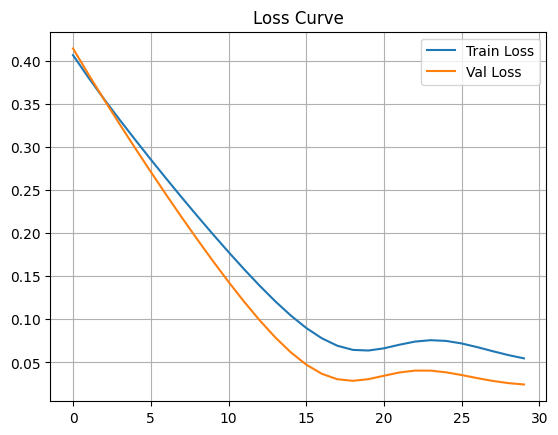

In [3]:
# Phần 2: Xây dựng mô hình RNN
# Import các thư viện cần thiết
import torch
import torch.nn as nn

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Định nghĩa mô hình RNN
class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # Lấy đầu ra của bước cuối cùng
        out = self.fc(out)
        return out
    
# Khởi tạo mô hình
model = RNNModel(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
EPOCHS = 30
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    
    output = model(X_train_t).squeeze()
    loss = criterion(output, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t).squeeze()
        val_loss = criterion(val_output, y_val_t)
    
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

# Test model
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t).squeeze()
    test_loss = criterion(test_pred, y_test_t)

print("Test Loss:", test_loss.item())

# Vẽ biểu đồ loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.grid()
plt.show()

MSE: 0.25905035367237644
MAE: 0.4701287146071446


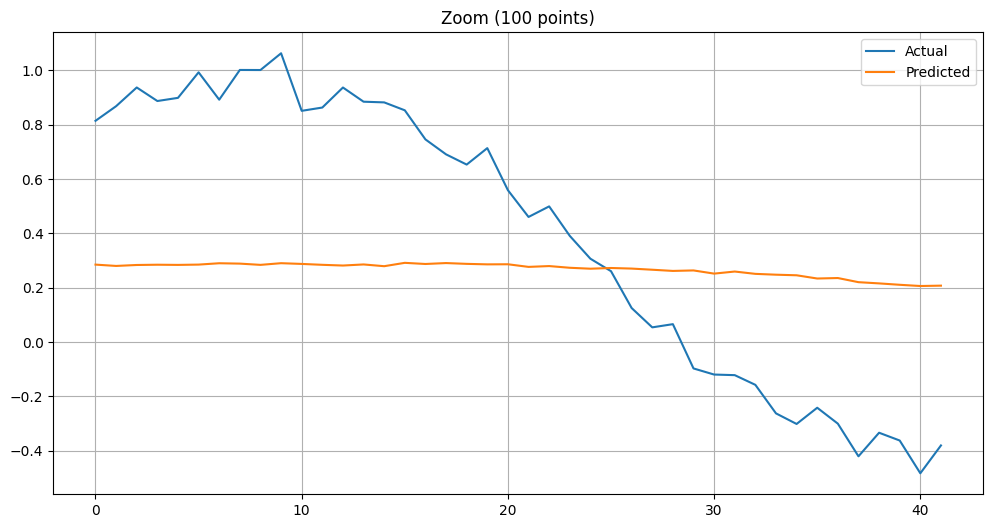

In [4]:
# Phần 3: Đánh giá và dự đoán mô hình
# Dự đoán trên tập test
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).squeeze().numpy()
    y_true = y_test_t.numpy()

# Inverse scaling về giá trị gốc
# Tạo mảng giả để inverse (vì scaler fit toàn bộ features)
temp_pred = np.zeros((len(y_pred), scaled_df.shape[1]))
temp_true = np.zeros((len(y_true), scaled_df.shape[1]))

# target là cột cuối
temp_pred[:, -1] = y_pred
temp_true[:, -1] = y_true

# inverse
y_pred_inv = scaler.inverse_transform(temp_pred)[:, -1]
y_true_inv = scaler.inverse_transform(temp_true)[:, -1]

# Tính các metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_true_inv, y_pred_inv)
mae = mean_absolute_error(y_true_inv, y_pred_inv)

print("MSE:", mse)
print("MAE:", mae)

# phóng to hơn để thấy rõ sự khác biệt
plt.figure(figsize=(12,6))
plt.plot(y_true_inv[:100], label="Actual")
plt.plot(y_pred_inv[:100], label="Predicted")
plt.legend()
plt.title("Zoom (100 points)")
plt.grid()
plt.show()

Seq Length Comparison: {10: 0.014127126894891262, 20: 0.004218362271785736, 30: 0.00937382597476244}
Hidden Size Comparison: {16: 0.022565895691514015, 32: 0.011755041778087616, 64: 0.00809972733259201}
Learning Rate Comparison: {0.01: 0.0008749195258133113, 0.001: 0.010823260061442852, 0.0001: 0.32844847440719604}


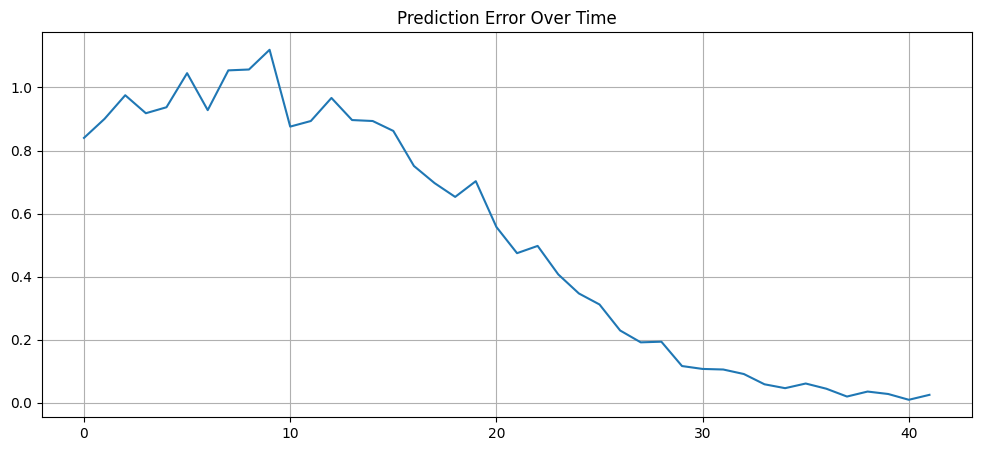

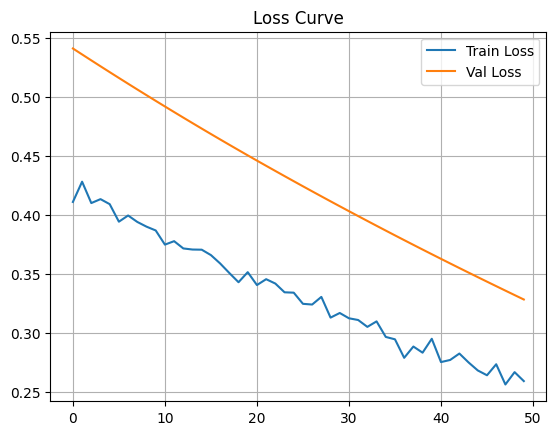

In [5]:
# Phần 4: Nâng cao
# Thử nhiều seq_length khác 
def prepare_data(seq_length):
    X, y = create_sequences(data_array, seq_length)

    train_size = int(0.7 * len(X))
    val_size = int(0.15 * len(X))

    return (
        X[:train_size], y[:train_size],
        X[train_size:train_size+val_size], y[train_size:train_size+val_size],
        X[train_size+val_size:], y[train_size+val_size:]
    )

# Model có dropout
class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1, dropout=0.2):
        super().__init__()
        
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)
    
# Hàm train chung
def train_model(X_train, y_train, X_val, y_val, hidden_size=32, lr=0.001, epochs=50):
    
    model = RNNModel(hidden_size=hidden_size)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)
    
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        output = model(X_train_t).squeeze()
        loss = criterion(output, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_output = model(X_val_t).squeeze()
            val_loss = criterion(val_output, y_val_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return model, train_losses, val_losses

# So sánh các seq_length
seq_list = [10, 20, 30]
results_seq = {}

for seq in seq_list:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_data(seq)
    
    model, train_loss, val_loss = train_model(X_train, y_train, X_val, y_val)
    
    results_seq[seq] = val_loss[-1]

print("Seq Length Comparison:", results_seq)

# So sánh các hidden_size
hidden_list = [16, 32, 64]
results_hidden = {}

X_train, y_train, X_val, y_val, X_test, y_test = prepare_data(20)

for h in hidden_list:
    model, train_loss, val_loss = train_model(X_train, y_train, X_val, y_val, hidden_size=h)
    results_hidden[h] = val_loss[-1]

print("Hidden Size Comparison:", results_hidden)

# So sánh các learning rate
lr_list = [0.01, 0.001, 0.0001]
results_lr = {}

for lr in lr_list:
    model, train_loss, val_loss = train_model(X_train, y_train, X_val, y_val, lr=lr)
    results_lr[lr] = val_loss[-1]

print("Learning Rate Comparison:", results_lr)

# Dự đoán nhiều bước
def multi_step_predict(model, input_seq, steps=3):
    model.eval()
    preds = []
    
    seq = input_seq.copy()
    
    for _ in range(steps):
        inp = torch.tensor(seq[np.newaxis, :, :], dtype=torch.float32)
        with torch.no_grad():
            pred = model(inp).item()
        
        preds.append(pred)
        
        new_row = np.append(seq[-1, :-1], pred)
        seq = np.vstack([seq[1:], new_row])
    
    return preds

# Vẽ lỗi theo thời gian
from sklearn.metrics import mean_squared_error

model.eval()
with torch.no_grad():
    pred = model(torch.tensor(X_test, dtype=torch.float32)).squeeze().numpy()

error = (pred - y_test)**2

plt.figure(figsize=(12,5))
plt.plot(error)
plt.title("Prediction Error Over Time")
plt.grid()
plt.show()

# Vẽ loss theo epoch
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.grid()
plt.show()
